In [2]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task1.ipynb")

# Homework 3 - Task 1: Regularized Regression
## Comparing Ridge and Lasso for Predicting Building Heating Load

---

### Background

Regression problems can often contain dozens of predictors that are correlated with each other, redundant, or simply noise. Standard linear regression struggles in these settings because it spreads coefficient estimates across correlated features, inflates variance, and can overfit.

**Regularization** addresses this by adding a penalty to the least-squares objective. Both Ridge and Lasso start from the standard least squares criterion:

$$\text{RSS} = \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2$$

and adds a penalty term that shrinks coefficient estimates toward zero, trading a small increase in bias for a potentially large reduction in variance.

---

### Dataset

Buildings account for a significant portion of global energy consumption. This dataset contains energy performance data for **768 building configurations** simulated with Ecotect software, varying across eight architectural variables:

| Predictor | Description |
|---|---|
| Relative Compactness | How compact the building's shape is |
| Surface Area | Total external surface area |
| Wall Area | Total area of the walls |
| Roof Area | Area of the roof |
| Overall Height | Height of the building |
| Orientation | Direction the building faces (encoded numerically) |
| Glazing Area | Percentage of facade that is glass |
| Glazing Area Distribution | Distribution of glazing (even vs. concentrated) |

#### Response Variable

| Column | Description |
|---|---|
| Heating Load (Y1) | Continuous target — heating energy requirements |

*Cooling Load (Y2) is also in the dataset but is not used in this assignment.*


More information on the dataset used in this lab can be found [here](https://archive.ics.uci.edu/dataset/242/energy+efficiency).

### Setup: Load libraries and read in data

Run the cell below to import all required packages and fetch the energy efficiency dataset from the UC Irvine Machine Learning Repository.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from ucimlrepo import fetch_ucirepo 
from sklearn.decomposition import PCA



### Step 1: Load the data

The cell below fetches the energy efficiency dataset from the UC Irvine Machine Learning Repository and converts it's contents to a dataframe. 

In [4]:
energy_efficiency = fetch_ucirepo(id=242)

feature_names = [
    "Relative Compactness", "Surface Area", "Wall Area", "Roof Area",
    "Overall Height", "Orientation", "Glazing Area", "Glazing Area Distribution"
]

df = energy_efficiency.data.features.copy()
df.columns = feature_names
df["Heating Load"] = energy_efficiency.data.targets.iloc[:, 0].values

df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84


### Step 2: Preprocess the data

Split the data into training and test sets using a 70/30 split and a `random_state` of 42. Then scale the data using `StandardScaler`. Name your scaled data `X_train_scaled` and `X_test_scaled`. 

In [5]:

X = df[feature_names] # X are predictors
y = df['Heating Load'] # y is the response

# Split train and text
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit scaler on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
grader.check("q1")

q1 results: All test cases passed!

### Step 3: Fit OLS Regression

Start with a plain OLS model as a baseline. Fit it on the training data. Calculate the MSE in a variable called `mse_ols` and inspect the coefficients.

In [22]:
# Prep ols
ols = LinearRegression()

# Fit to unscaled training data
ols.fit(X_train, y_train)

# Get MSE
mse_ols = mean_squared_error(y_test, ols.predict(X_test))

mse_ols


8.840180473905805

In [23]:
grader.check("q2")

q2 results: All test cases passed!

### Step 4: Fit Ridge with Cross-Validation

So far you've selected hyperparameters by manually looping over values and using `cross_val_score` to evaluate each one. `RidgeCV` does exactly the same thing. It's a convenience wrapper that handles that loop for you internally. Ft a `RidgeCV` model using the following lambda values: `np.logspace(-4,4, 100)` and`cv` of 10. Create a table comparing the coefficients for both OLS and Ridge. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Ridge Coefficient`. 

```python
# What you've done before:
for lambda in lambdas:
    ridge = Ridge(alpha=lambda)
    scores = cross_val_score(ridge, X_train, y_train, cv=10, scoring='neg_mean_squared_error')
    ...

# What RidgeCV does under the hood (same idea, built in):
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
ridge_cv.alpha_   # Lambda with the best CV score
```

After calling `.fit()`, `ridge_cv` behaves like a regular fitted `Ridge` model. You can call `.predict()`, inspect `.coef_`, and so on. The best lambda is stored in `ridge_cv.alpha_`.

In [7]:
lambdas = np.logspace(-4, 4, 100)

ridge_cv = RidgeCV(alphas = lambdas, cv = 10, scoring = 'neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train) # Ridge_cv needs scaled data
ridge_cv.alpha_ # Lambda with the best CV score

print(f"Best lambda: {ridge_cv.alpha_:.4f}")

# Make table to compare coefficients for OLS and Ridge
table = pd.DataFrame({
    'Feature': feature_names,
    'OLS Coefficient': ols.coef_,
    'Ridge Coefficient': ridge_cv.coef_
})
print(table)




Best lambda: 0.2057
                     Feature  OLS Coefficient  Ridge Coefficient
0       Relative Compactness    -6.386753e+01          -6.352418
1               Surface Area    -8.736463e+09          -3.474392
2                  Wall Area     8.736463e+09           0.816587
3                  Roof Area     1.747293e+10          -3.797180
4             Overall Height     4.125574e+00           7.306373
5                Orientation    -2.357210e-02          -0.025299
6               Glazing Area     1.992667e+01           2.670852
7  Glazing Area Distribution     2.307234e-01           0.356417


In [43]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: Is the penalty term doing its job?  How can you tell?**

Yes. The OLS coefficients for Surface Area, Wall Area, and Roof Area are extremely high, which indicates they are highly correlated. Ridge is shrinking these values to be less than 10 (they were in the billions), which is exactly what the penalty term is supposed to do.

<!-- END QUESTION -->

### Step 5: Evaluate Ridge Model

Use the cross-validated ridge model from Step 4 to predict on the test set and compute MSE.

In [8]:
# Use ridge model 
y_test_pred_rcv = ridge_cv.predict(X_test_scaled)

# MSE between y_test and ridge results
mse_rcv = mean_squared_error(y_test, y_test_pred_rcv)
print(f"Ridge CV MSE: {mse_rcv:.4f}")


Ridge CV MSE: 8.8440


In [45]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 6: Ridge Coefficient Path

Now, create a plot looking at the coefficient values against lambda (similar to the one introduced in the [Regularization Notes)](https://meds-eds-232.github.io/EDS-232-course-website/notes/6_linear_model_selection_and_regularization/6_linear_model_selection_and_regularization-NOTES.html). Start by fitting a Ridge model for the values of lambda defined in Step 4. Then create a plot of the ridge regression coefficient profiles. Each feature should be plotted, with their coefficient value on the y axis and lambda values on the x axis. 

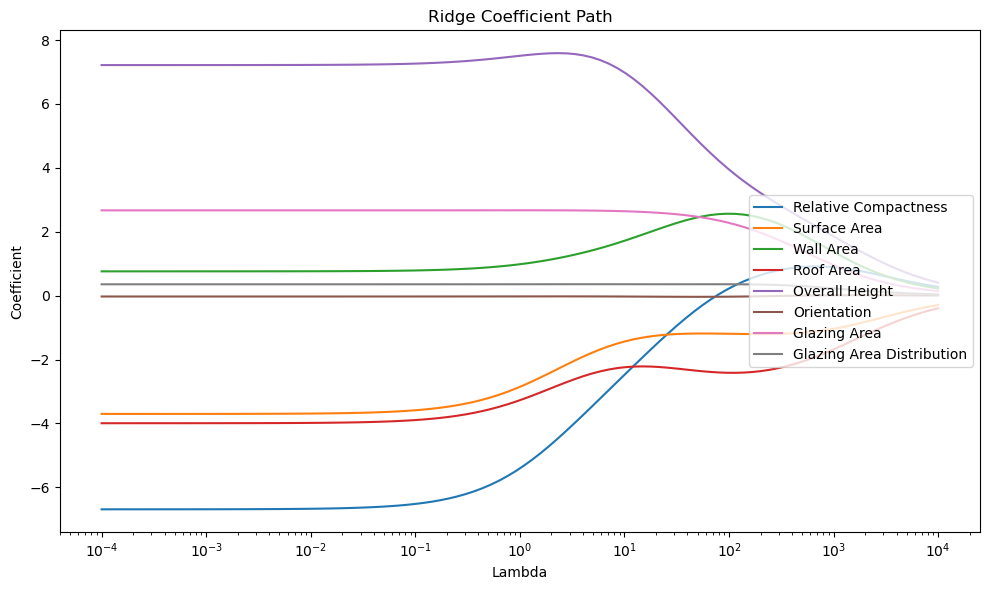

In [9]:
# From lab 5
coefficients = []
for lam in lambdas:
    ridge = Ridge(alpha=lam)
    ridge.fit(X_train_scaled, y_train)
    coefficients.append(ridge.coef_)

coefficients = np.array(coefficients)

plt.figure(figsize=(10, 6))

# Plot lambdas for each value - lab 5
for i, feature in enumerate(feature_names):
    plt.plot(lambdas, coefficients[:, i], label=feature)

plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Coefficient')
plt.title('Ridge Coefficient Path')
plt.legend(loc='right')
plt.tight_layout()
plt.show()




> **Q2: Which 2 predictors appear to be most important in the coefficient profile above? Explain your answer.**

Roof area and overall height. The most 'important' coefficients will be the coefficients that aren't shrunk to zero as the Lambda increases and Ridge is doing it's penalization. Roof area and overall height are resistant to the 'shrinkage' that Ridge forces, indicating they have the strongest realtionship with the response.

<!-- END QUESTION -->

### Step 7: Fit Lasso with Cross-Validation

Now fit a `LassoCV` model using the same lambda range and 10-fold CV. Create a table comparing the coefficients for both OLS and Lasso. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Lasso Coefficient`. 

In [10]:
# Initiate lasso
lasso_cv = LassoCV(alphas=lambdas, cv=10)
# Fit lasso
lasso_cv.fit(X_train_scaled, y_train)

print(f"Best lambda: {lasso_cv.alpha_:.4f}")

# Create table
table_lasso = pd.DataFrame({
    'Feature': feature_names,
    'OLS Coefficient': ols.coef_,
    'Lasso Coefficient': lasso_cv.coef_
})
print(table_lasso)



Best lambda: 0.0016
                     Feature  OLS Coefficient  Lasso Coefficient
0       Relative Compactness    -6.386753e+01          -6.418330
1               Surface Area    -8.736463e+09          -6.231035
2                  Wall Area     8.736463e+09           2.152524
3                  Roof Area     1.747293e+10          -1.044324
4             Overall Height     4.125574e+00           7.309160
5                Orientation    -2.357210e-02          -0.023593
6               Glazing Area     1.992667e+01           2.670194
7  Glazing Area Distribution     2.307234e-01           0.354971


In [51]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q3: Did lasso shrink the coefficients in the same way Ridge did? Comment on any differences.**

_Type your answer here, replacing this text._

<!-- END QUESTION -->

### Step 8: Evaluate Lasso Model

Use the cross-validated lasso model from Step 7 to predict on the test set and compute MSE.

In [11]:
# Make predictions from lasso cv model
y_test_pred_lcv = lasso_cv.predict(X_test_scaled)

# Find MSE between test and predictions
mse_lcv = mean_squared_error(y_test, y_test_pred_lcv)
print(f"Lasso CV MSE: {mse_lcv:.4f}")

Lasso CV MSE: 8.8416


In [53]:
grader.check("q6")

q6 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 9: Compare Ridge and Lasso

Now that both models are fitted and evaluated, create the following: 
- A table comparing the Test MSE for OLS, Ridge CV, and Lasso CV.
- A singular plot to show how MSE responds to regularization strength across all alphas (for both lasso CV and ridge CV)
- A bar plot showing how coefficient estimates differ for OLS, Lasso CV, and Ridge CV

Write 1 -2 sentences explaining the results for each plot.


*Hint: Refer back to Lab 5 for help with code on both these plots!*

In [ ]:
# Display OLS, Ridge, and Lasso MSE
results = pd.DataFrame({
    'Model': ['OLS', 'Ridge CV', 'Lasso CV'],
    'Test MSE': [mse_ols, mse_rcv, mse_lcv]
})
print(results)

      Model  Test MSE
0       OLS  8.840180
1  Ridge CV  8.843961
2  Lasso CV  8.841571


Results are all very similar, but there are differences. OLS has the lowest Test MSE, then Lasso, the Ridge - but the small difference between them suggests Ridge and Lasso are not really improving on OLS.

/Users/henryoliver/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.397e+01, tolerance: 5.455e+00
  model = cd_fast.enet_coordinate_descent(
/Users/henryoliver/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.924e+01, tolerance: 5.455e+00
  model = cd_fast.enet_coordinate_descent(
/Users/henryoliver/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations

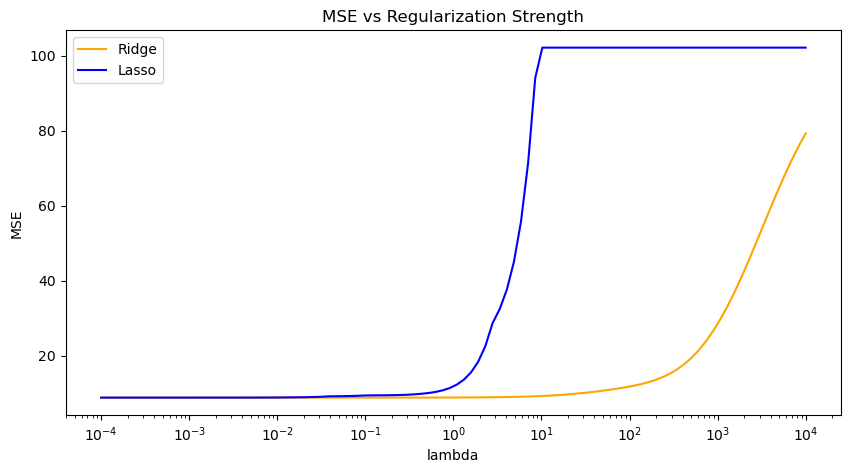

In [13]:
# initiate empty list to fill with results
ridge_mse_vals = []
lasso_mse_vals = []

# Run ridge, lasso, and MSE for each on scaled data
for lam in lambdas:
    ridge = Ridge(alpha=lam).fit(X_train_scaled, y_train)
    lasso = Lasso(alpha=lam).fit(X_train_scaled, y_train)
    ridge_mse_vals.append(mean_squared_error(y_test, ridge.predict(X_test_scaled)))
    lasso_mse_vals.append(mean_squared_error(y_test, lasso.predict(X_test_scaled)))

# Plot results (from lab 5)
plt.figure(figsize=(10, 5))
plt.plot(lambdas, ridge_mse_vals, label='Ridge', color='orange')
plt.plot(lambdas, lasso_mse_vals, label='Lasso', color='blue')
plt.xscale('log')
plt.xlabel('lambda')
plt.ylabel('MSE')
plt.title('MSE vs Regularization Strength')
plt.legend()
plt.show()




The plot above communicates how sensitive each method is to the choice of lambda. Lasso is clearly more sensitive, as it climbs from 0-100 MSE between lambdas of 1-10. This makes sense because lasso's penalty brings coefficients to 0, which makes predictions less accurate more quickly.

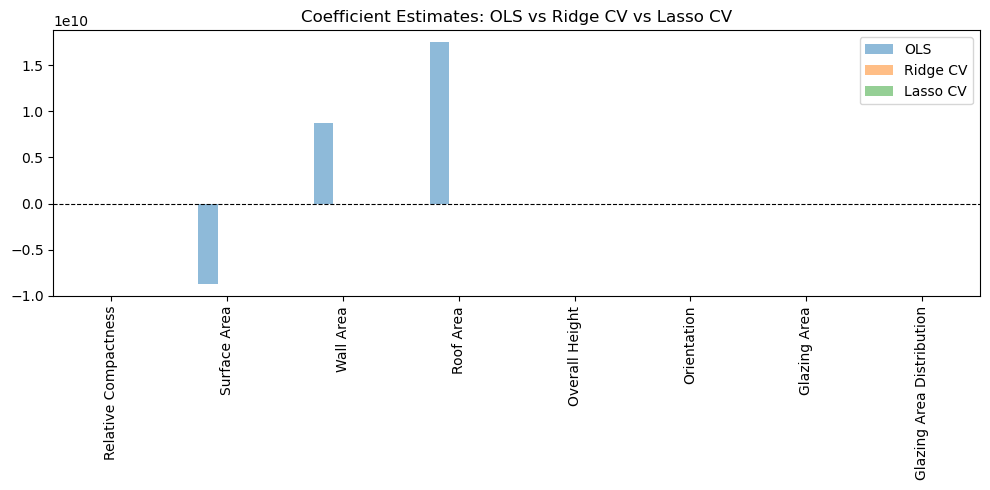

In [37]:

coeffs = pd.DataFrame({
    'OLS': ols.coef_,
    'Ridge CV': ridge_cv.coef_,
    'Lasso CV': lasso_cv.coef_
}, index=feature_names)


coeffs.plot.bar(figsize=(10, 5), alpha = 0.5)
plt.title('Coefficient Estimates: OLS vs Ridge CV vs Lasso CV')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

In [42]:
print(coeffs)

                                    OLS  Ridge CV  Lasso CV
Relative Compactness      -6.386753e+01 -6.352418 -6.418330
Surface Area              -8.736463e+09 -3.474392 -6.231035
Wall Area                  8.736463e+09  0.816587  2.152524
Roof Area                  1.747293e+10 -3.797180 -1.044324
Overall Height             4.125574e+00  7.306373  7.309160
Orientation               -2.357210e-02 -0.025299 -0.023593
Glazing Area               1.992667e+01  2.670852  2.670194
Glazing Area Distribution  2.307234e-01  0.356417  0.354971


My plot does not show the results of coefficients for Ridge and Lasso, because the coefficients for OLS were so astronomically high, but we do see that Wall Area, Roof Area, and Surface Area are likely very correlated with eachother. Given how surfaces in buildings work, this makes sense.

> **Q4: Which model would you pick for this dataset? Why?**


Lasso, because we know that the Surface area, wall area and roof area variables are multicollinear, so it's fine if we just send them to 0.

<!-- END QUESTION -->

---

## Part 2: Principal Components Regression (PCR)

### Background

**Principal Component Analysis (PCA)** is a dimensionality-reduction technique whose goal is to *capture as much about the data as possible in as few dimensions as possible*. It does this by finding a new set of axes — the **principal components (PCs)** — where:

- **PC1** points in the direction of **maximum variance** in the data.
- **PC2** is orthogonal to PC1 and points in the next direction of greatest remaining variance.
- Each subsequent component is orthogonal to all previous ones and explains less variance.

Each observation gets a new coordinate in this rotated space called a **score**. The contribution of each original feature to a PC is called a **loading**.

The **Proportion of Variance Explained (PVE)** measures each component's share of total variance. A common rule of thumb is to keep enough components to explain **90–95% of the total variance**.

---

**Principal Components Regression (PCR)** connects unsupervised PCA structure to a supervised response:

1. **Standardize** the predictors.
2. **Compute** the principal components.
3. **Project** the observations onto *M* components (the scores).
4. **Fit OLS** on the projected data (the *M* scores) rather than the original features.

The key assumption is that *"directions in which the predictors show the most variation are often also the directions most strongly associated with the response."* By discarding low-variance components we reduce noise, not signal.

---

**How PCR differs from Ridge and Lasso:**

| | Ridge | Lasso | PCR |
|---|---|---|---|
| Mechanism | L2 penalty shrinks all coefs | L1 penalty can zero out coefs | Drops low-variance directions |
| Variable selection? | No | Yes (exact zeros) | No — uses linear combinations of *all* predictors |
| Tuning parameter | λ (penalty strength) | λ (penalty strength) | *M* (number of components) |

Unlike Lasso, **PCR cannot perform variable selection** — every original feature still contributes to each PC. Lasso tends to outperform PCR when truly irrelevant predictors exist, because it can set those coefficients exactly to zero.

### Step 10: Fit PCA and Inspect Explained Variance

In the cells below:
1. Fit a `PCA` object on `X_train_scaled` using all 8 components.
2. Store the explained variances in a variable called `explained_var` and the cumulative variance in a variable called `cumulative_var`. Print a table showing each component's individual and cumulative explained variance (%).
3. Create a plot with:
   - A **bar chart** showing the individual explained variance (%) for each component.
   - A **line plot** overlaid showing the cumulative explained variance (%).

Use the plot to identify where cumulative variance first reaches ~90% and where the "elbow" in the bar chart occurs. You'll use this to choose *k* in the next step.

After fitting a `PCA` object, two attributes give you the variance information you need:

```python
pca.explained_variance_ratio_      # Array of length n_components
                                   # Each value = fraction of total variance explained by that PC
                                   # E.g. [0.45, 0.30, ...] means PC1 explains 45%, PC2 explains 30%

np.cumsum(pca.explained_variance_ratio_)   # Cumulative variance total used for finding the "elbow" and checking how many components hit the 90% threshold
                                           
```

   Component  Explained Variance (%)  Cumulative Variance (%)
0          1            4.629048e-01                 0.462905
1          2            1.563182e-01                 0.619223
2          3            1.497484e-01                 0.768971
3          4            1.243148e-01                 0.893286
4          5            9.966322e-02                 0.992949
5          6            6.477268e-03                 0.999427
6          7            5.733790e-04                 1.000000
7          8            2.730130e-32                 1.000000


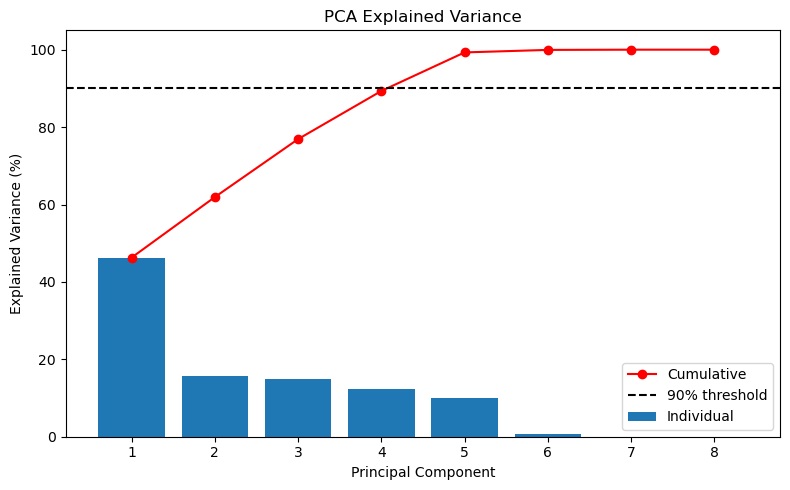

In [59]:
## I had AI help me with this portion, the comments are mine after researching the code.

# Fit Principal component analysis (PCA), on an 8-step PCA
pca_full = PCA(n_components=8)
pca_full.fit(X_train_scaled)

# Explained_var output
explained_var = pca_full.explained_variance_ratio_

# Cumulative var output
cumulative_var = np.cumsum(explained_var)
explained_var
cumulative_var

# Make table of each PCA component
pca_table = pd.DataFrame({
    'Component': range(1, 9),
    'Explained Variance (%)': explained_var,
    'Cumulative Variance (%)': cumulative_var
})
print(pca_table)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
# Bar plot shows how much bariacne is explained by each individual step in the 8-step PCA
ax.bar(range(1, 9), explained_var*100, label='Individual')
# Red line shows summed cumulative variance explained by each step of PCA
ax.plot(range(1, 9), cumulative_var*100, marker='o', color='red', label='Cumulative')
# Threshold line at 90% of variance explained
ax.axhline(90, color='black', linestyle='--', label='90% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('PCA Explained Variance')
ax.legend()
plt.tight_layout()
plt.show()



In [56]:
grader.check("q7")

q7 results: All test cases passed!

NOTE: This graph was producing a much more effective visual when `explained_var` was expressed as a percent
`explained_var = pca_full.explained_variance_ratio_*100` - but the autograder wouldn't accept my answer until I removed the *100 bit.

<!-- BEGIN QUESTION -->

> **Q5: How many principal components does it take to explain at least 90% of the variance in the features?**

It takes 5 principal components to explain at least 90% of the variance in the features.

<!-- END QUESTION -->

### Step 11: Fit the Final PCR Model

PCR follows four concrete steps:

1. **Standardize the predictors** (mean 0, SD 1) (done in Step 2 with `StandardScaler`)
2. **Compute the principal components** of the standardized predictors (done in Step 10 with `PCA`)
3. **Project each observation onto the first *k* components** ( `pca_final.transform()` gives you the scores)
4. **Fit OLS of y on this new projected data** (`LinearRegression` on the PC scores)

You have already done steps 1 and 2. Now, set `best_k` based on the "elbow" or ~90% cumulative variance threshold from your plot above. Then carry out steps 3 and 4 by initializing `PCA(n_components = best_k`), transforming with `X_train_scaled` and `X_test_scaled`, and then fitting a `LinearRegression` with this transformed data. 

In [57]:
# Set k based on elbow / ~90% cumulative variance threshold
best_k = 4

# Fit PCA with best_k components
pca_final = PCA(n_components=best_k)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

# Fit OLS on PCA-transformed data
ols_pcr = LinearRegression()
ols_pcr.fit(X_train_pca, y_train)

# Predict and compute MSE
y_pred_pcr = ols_pcr.predict(X_test_pca)
mse_pcr = mean_squared_error(y_test, y_pred_pcr)
print(f"PCR MSE: {mse_pcr:.4f}")

PCR MSE: 14.5239


<!-- BEGIN QUESTION -->

> **Q6: What value of k did you pick? Why?**


4, because it is right at about the 90% variance threshold that we set

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

---

## Final Comparison: OLS, Ridge, Lasso, and PCR

Now that all four models have been fitted and evaluated, bring the results together.

### Step 12: Summary Table

Build a summary table comparing the test MSE across all four models. Your table should have three columns: `Model`, `Tuning Parameter` (specify the lambda/ number of components chosen), and `Test MSE`. 

For PCR to perform well a key assumption must hold: the directions that show the most variation in the predictors are also the directions most strongly associated with the response. Lasso and ridge aim to shrink the coefficients associated with predictors wit little predictive value.

> **Q7: Comment on the results in the table above. Which model performs best? Are the differences meaningful, or do the models perform similarly? What might explain the pattern you see?**

_Type your answer here, replacing this text._

<!-- END QUESTION -->



---

Run the cell below to receive credit for the augotraded questions. 

In [ ]:
grader.check_all()